<a href="https://colab.research.google.com/github/toombsc/toombsc/blob/main/Permitting_Activity_in_Orleans_Parish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# WHERE THE DATA COMES FROM
#   data.nola.gov
#
# Why each cleaning step exists
#   A. ConstrVal is text with commas ("1,478,606"). Naive numeric parsing
#      silently drops every large value. Strip commas first.
#   B. Large projects file one permit per unit, with the FULL project value
#      copied onto every unit permit. Summing overstates value ~3x.
#      Fix: count each distinct value >= $250k once, at first filing.
#   C. Zoning and CouncilDist are truncated at export ("HU-RD2,HU-", "B,").
#      Take the first value and flag multi-district rows.
# =============================================================================
# WHY NEIGHBORHOOD
#   The Subdivision column holds the City Planning Commission neighborhood
#   name (178 of them). Subdivision is 99.7% populated, which is better
#   coverage than most fields here.
#
# =============================================================================

In [ ]:
#### CELL M0 — download directly from data.nola.gov #############################
# Colab pulls from the portal, which is much faster.

import pandas as pd

DATASETS = {
    "permits": "rcm3-fn58",
    "blds":    "72f9-bi28",
}

def url(dsid):
    return f"https://data.nola.gov/api/views/{dsid}/rows.csv?accessType=DOWNLOAD"

paths = {}
for kind, dsid in DATASETS.items():
    if "PUT-ID" in dsid:
        print(f"  skipping {kind}: no dataset id set")
        continue
    fname = f"{kind}.csv"
    !wget -q --show-progress -O {fname} "{url(dsid)}"
    paths[kind] = fname
    print(f"  {kind:8s} downloaded")


permits.csv             [           <=>      ] 156.00M  7.97MB/s    in 20s     
  permits  downloaded
blds.csv                [         <=>        ] 234.55M  8.67MB/s    in 27s     
  blds     downloaded


In [ ]:
#### CELL 2 settings ##########################################################

VALUE_DEDUP_THRESHOLD = 250_000   # distinct-value rule applies at/above this
PROJECT_GAP_DAYS      = 90        # new filing after this gap = new project
FIRST_FULL_YEAR       = 2015      # partial years excluded from annual tables
LAST_FULL_YEAR        = 2025
COMMERCIAL_LANDUSE    = ["Business Use", "Mixed Use"]

import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

In [ ]:
#### CELL M1 merge, clean, and validate #######################################

# ---- base: the permits file -------------------------------------------------
P = pd.read_csv(paths["permits"], low_memory=False)
print(f"base permits: {len(P):,} rows")
assert P["NumString"].is_unique, "NumString is not unique - investigate before merging"


# ---- helper: match columns regardless of case, spaces, or underscores -------
def load_subset(path, wanted, key, label):
    """Read only `wanted` columns from path, matching names loosely.
    Renames them back to the canonical spellings in `wanted`.
    Raises if `key` is absent, warns for anything else missing."""
    header = pd.read_csv(path, nrows=0).columns.tolist()
    norm = {c.lower().replace(" ", "").replace("_", ""): c for c in header}

    cols, renames = [], {}
    for w in wanted:
        k = w.lower().replace(" ", "").replace("_", "")
        if k in norm:
            cols.append(norm[k])
            renames[norm[k]] = w
        else:
            print(f"  {label}: column not found, skipping -> {w}")

    if key not in renames.values():
        raise RuntimeError(
            f"{label}: no '{key}' column found. Columns present: {header[:12]}")

    out = pd.read_csv(path, low_memory=False, usecols=cols).rename(columns=renames)
    out = out.sort_values(key).drop_duplicates(key, keep="first")
    print(f"  {label}: {len(out):,} rows after dedupe, {len(cols)} columns")
    return out

A = None
if "apps" in paths:
    try:
        A = load_subset(paths["apps"], key="PermitNumber", label="applications", wanted=[
            "PermitNumber", "Application submitted", "Permit approved",
            "Days to Approved", "Days to Issue Date", "Days to Plan Review",
            "Days to Zoning Review", "Days to first inspection",
            "SubmittalType", "Reason"])
    except RuntimeError as e:
        print(f"  skipping applications: {e}")

B = load_subset(paths["blds"], key="PermitNum", label="BLDS", wanted=[
    "PermitNum", "ContractorCompanyName", "ContractorTrade",
    "ContractorLicNum", "Fee", "EstProjectCost", "TotalSqFt",
    "PermitClassMapped", "WorkClassMapped", "ExpiresDate", "COIssuedDate"])

df = P.copy()
if A is not None:
    df = df.merge(A, left_on="NumString", right_on="PermitNumber", how="left")
df = df.merge(B, left_on="NumString", right_on="PermitNum", how="left")
assert len(df) == len(P), "row count changed - a duplicate key slipped through"
print(f"\nmerged: {len(df):,} rows x {df.shape[1]} columns")

# ---- merge ------------------------------------------------------------------
df = P.copy()

if A is not None:
    df = df.merge(A, left_on="NumString", right_on="PermitNumber", how="left")
    print("  merged in applications")
else:
    print("  no applications data - processing-time cells will not work")

df = df.merge(B, left_on="NumString", right_on="PermitNum", how="left")
assert len(df) == len(P), "row count changed - a duplicate key slipped through"
print(f"\nmerged: {len(df):,} rows x {df.shape[1]} columns")

# strip commas BEFORE numeric conversion. This parses EstProjectCost,
# TotalSqFt, Fee, ConstrVal.
def parse_money(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce")

for col in ["ConstrVal", "EstProjectCost", "TotalSqFt", "Fee", "BldgArea"]:
    if col in df.columns:
        df[col + "_n"] = parse_money(df[col])
df["cv"] = df["ConstrVal_n"]
df["fd"] = pd.to_datetime(df["FilingDate"], errors="coerce", format="mixed")

n0 = len(df)
df = df[~df["CurrentStatus"].astype(str).str.upper().str.startswith("VOIDED")].copy()
print(f"removed {n0 - len(df):,} voided/withdrawn permits")

# project totals repeated across unit-level permits
df = df.sort_values("fd").reset_index(drop=True)
df["val_counted"] = df["cv"]
big = df["cv"] >= VALUE_DEDUP_THRESHOLD
dup = df.loc[big].duplicated(subset=["cv"])
df.loc[df.loc[big].index[dup.values], "val_counted"] = 0
print(f"value-zeroed {int(dup.sum()):,} duplicate-value permits")

# KNOWN SOURCE ERROR: the H3C development at 1300 Oretha Castle Haley carries
# $337,458,900 in all three datasets which is about twice as large as all of
# Finance New Orleans' reported PILOT projects in 2021 combined.
# Finance New Orleans, Gulf Coast Housing Partnership and many news sources
# state the total development cost was ~$78-80M (total development cost,
# which is itself broader than a construction contract. Correction here sourced
# from GCHP; remove this block if the city fixes the underlying record.
h3c = (df["Address"].astype(str).str.contains("Oretha Castle Haley", case=False, na=False)
       & df["Owner"].astype(str).str.contains("AG 2018|Finance Authority|Och Commercial",
                                              case=False, na=False))
if h3c.any():
    df.loc[h3c, "val_counted"] = 0
    df.loc[df[h3c].sort_values("fd").index[0], "val_counted"] = 77_873_707
    print(f"H3C corrected: {int(h3c.sum()):,} permits -> single $77.9M entry")

# base address, then project clustering
df["base_addr"] = (df["Address"].astype(str)
    .str.replace(r"(?i),?\s*(apt|unit|ste|suite|floor|fl|bldg|building|#)\s*[\w\-]+.*$",
                 "", regex=True)
    .str.replace(r",.*$", "", regex=True).str.strip().str.upper())
df = df.sort_values(["base_addr", "Owner", "fd"])
gap = df.groupby(["base_addr", "Owner"])["fd"].diff().dt.days
df["proj_id"] = (gap.isna() | (gap > PROJECT_GAP_DAYS)).cumsum()
print(f"{len(df):,} permits -> {df['proj_id'].nunique():,} projects")

# untruncate fields
df["council"] = df["CouncilDist"].astype(str).str.rstrip(",").str.strip()
df.loc[~df["council"].isin(list("ABCDE")), "council"] = "Unassigned/Multi"
df["zone_primary"] = df["Zoning"].astype(str).str.split(",").str[0].str.strip()
df["zone_multi"]   = df["Zoning"].astype(str).str.contains(",")

# two commercial definitions
df["comm"]      = df["LandUse"].isin(COMMERCIAL_LANDUSE)          # original
df["comm_blds"] = df["PermitClassMapped"].eq("Non-Residential")   # broader
df["yr"] = df["fd"].dt.year.astype("Int64")
df["ym"] = df["fd"].dt.to_period("M")

print("\n=== COVERAGE OF THE MERGED-IN FIELDS ===")
for c in ["Days to Issue Date", "Days to Approved", "ContractorCompanyName",
          "PermitClassMapped", "Fee_n"]:
    if c in df.columns:
        nn = df[c].notna().sum()
        print(f"  {c:24s} {nn:>7,} ({nn/len(df)*100:5.1f}%)")

print("\n=== COMMERCIAL ACTIVTY CHANGE UNDER BOTH DEFINITIONS ===")
full = df[(df["yr"] >= FIRST_FULL_YEAR) & (df["yr"] <= LAST_FULL_YEAR)]
for flag, label in [("comm", "LandUse (Business/Mixed)"),
                    ("comm_blds", "BLDS (Non-Residential)")]:
    s = full[full[flag]].groupby("yr").size()
    pre, post = s.loc[2015:2019].mean(), s.loc[2022:2025].mean()
    print(f"  {label:26s} {pre:,.0f}/yr -> {post:,.0f}/yr = {(post/pre-1)*100:+.1f}%")

print("\nready: `df` is merged and cleaned. Continue with CELL 4.")


#### OPTIONAL — save the merged file ############################################
# The full merge is large (about 170 MB). This saves a slimmer analysis-ready
# version instead, which is what you actually need for the charts and tables.

keep = ["NumString", "fd", "yr", "Address", "base_addr", "Owner", "LandUse",
        "Type", "CurrentStatus", "cv", "val_counted", "proj_id",
        "Zoning", "zone_primary", "council", "Subdivision", "HistoricDistrict",
        "Location 1", "comm", "comm_blds", "PermitClassMapped",
        "Days to Approved", "Days to Issue Date",
        "ContractorCompanyName", "ContractorTrade", "Fee_n"]
slim = df[[c for c in keep if c in df.columns]]
slim.to_csv("permits_merged_slim.csv", index=False)
print(f"saved permits_merged_slim.csv: {slim.shape[0]:,} rows x {slim.shape[1]} cols")

# from google.colab import files
# files.download("permits_merged_slim.csv")

base permits: 345,113 rows
  BLDS: 459,650 rows after dedupe, 11 columns

merged: 345,113 rows x 53 columns
  no applications data - processing-time cells will not work

merged: 345,113 rows x 53 columns
removed 1,962 voided/withdrawn permits
value-zeroed 7,184 duplicate-value permits
H3C corrected: 322 permits -> single $77.9M entry
343,151 permits -> 244,880 projects

=== COVERAGE OF THE MERGED-IN FIELDS ===
  ContractorCompanyName    244,393 ( 71.2%)
  PermitClassMapped        336,999 ( 98.2%)
  Fee_n                    336,999 ( 98.2%)

=== COMMERCIAL ACTIVTY CHANGE UNDER BOTH DEFINITIONS ===
  LandUse (Business/Mixed)   6,420/yr -> 3,014/yr = -53.1%
  BLDS (Non-Residential)     8,051/yr -> 3,408/yr = -57.7%

ready: `df` is merged and cleaned. Continue with CELL 4.
saved permits_merged_slim.csv: 343,151 rows x 24 cols


In [ ]:
##### CELL 4 — annual summary ####################################################

full = df[(df["yr"] >= FIRST_FULL_YEAR) & (df["yr"] <= LAST_FULL_YEAR)]

annual = full.groupby("yr").agg(
    permits=("fd", "size"),
    projects=("proj_id", "nunique"),
    value=("val_counted", "sum"))
annual["comm_permits"]  = full[full["comm"]].groupby("yr").size()
annual["comm_projects"] = full[full["comm"]].groupby("yr")["proj_id"].nunique()
annual["comm_value"]    = full[full["comm"]].groupby("yr")["val_counted"].sum()

annual   # in Colab, a bare variable on the last line displays as a table

,permits,projects,value,comm_permits,comm_projects,comm_value
yr,,,,,,
2015,27193,20042,1032922780,7569,5280,608241338
2016,25506,20887,1259418977,5821,4652,833898058
2017,26593,22628,1691289815,6307,5272,1148188975
2018,25714,21457,979690098,6295,4710,569384914
2019,22918,19143,951071791,6108,4876,564007392
2020,20439,11431,1769659237,4362,2475,1114897430
2021,19796,11530,1463465288,3765,2133,1000883569
2022,19916,12197,1655750230,3131,2333,1169544277
2023,19019,11513,1322881502,3281,2250,827017602


In [ ]:
#### CELL 5 — trend tests #######################################################
# Always run OLS and Theil-Sen, then rerun with the edge months dropped.
# If a result loses significance when one month leaves, do not report it.

monthly = full.groupby("ym").agg(
    permits=("fd", "size"),
    projects=("proj_id", "nunique"),
    value=("val_counted", "sum")).sort_index()

def trend(series, label):
    t = np.arange(len(series))
    ols = st.linregress(t, series.values)
    ts  = st.theilslopes(series.values, t)
    flag = "SIGNIFICANT" if ols.pvalue < 0.05 else "no trend"
    print(f"  {label:10s} OLS {ols.slope:+12.1f}/mo  p={ols.pvalue:.4f}"
          f" | Theil-Sen {ts[0]:+10.1f} (CI {ts[2]:+.1f}, {ts[3]:+.1f})  {flag}")

print("MONTHLY TRENDS (full window)")
for col in ["permits", "projects", "value"]:
    trend(monthly[col], col)

print("\nMONTHLY TRENDS (edge months dropped)")
for col in ["permits", "projects", "value"]:
    trend(monthly[col].iloc[1:-1], col)

MONTHLY TRENDS (full window)
  permits    OLS         -7.6/mo  p=0.0000 | Theil-Sen       -7.6 (CI -8.8, -6.5)  SIGNIFICANT
  projects   OLS         -7.8/mo  p=0.0000 | Theil-Sen       -7.5 (CI -8.6, -6.4)  SIGNIFICANT
  value      OLS    +168600.7/mo  p=0.3718 | Theil-Sen   +43891.6 (CI -132032.0, +225329.9)  no trend

MONTHLY TRENDS (edge months dropped)
  permits    OLS         -7.5/mo  p=0.0000 | Theil-Sen       -7.5 (CI -8.6, -6.3)  SIGNIFICANT
  projects   OLS         -7.8/mo  p=0.0000 | Theil-Sen       -7.6 (CI -8.7, -6.4)  SIGNIFICANT
  value      OLS    +172708.1/mo  p=0.3738 | Theil-Sen   +40763.2 (CI -146833.6, +229777.5)  no trend


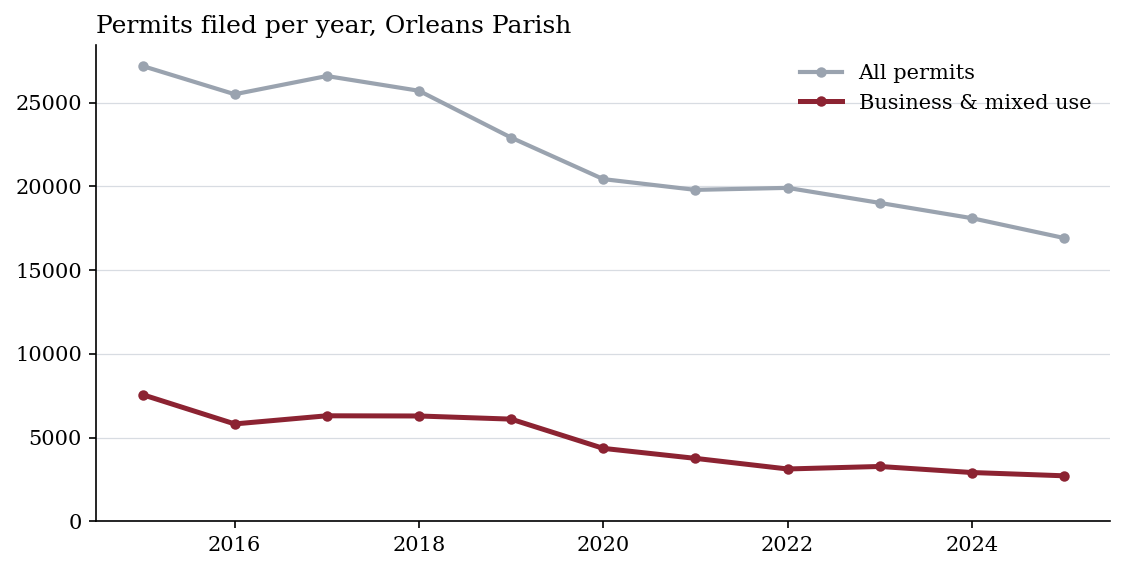

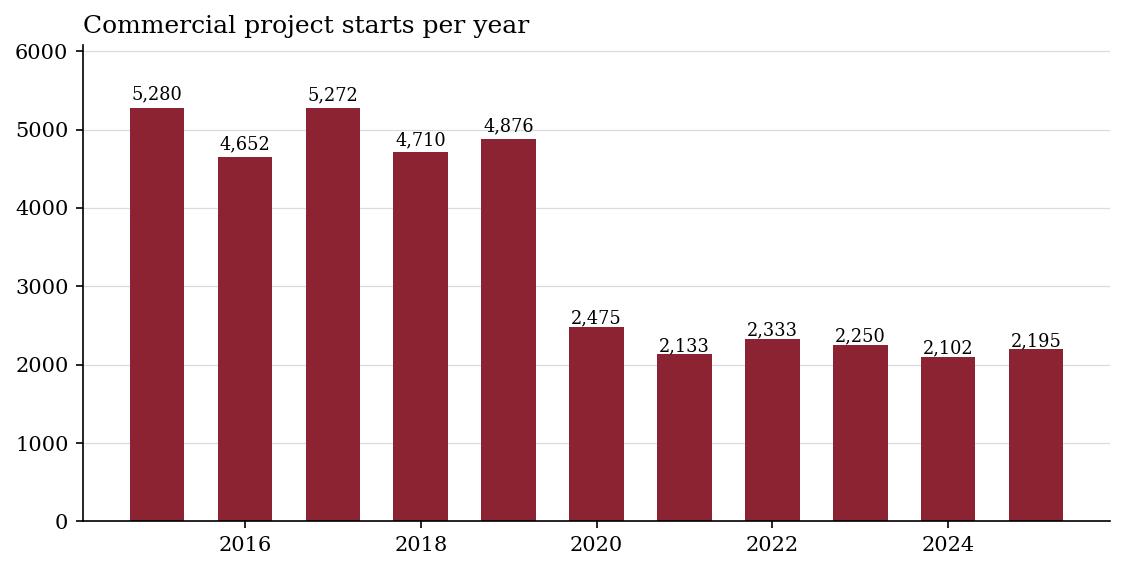

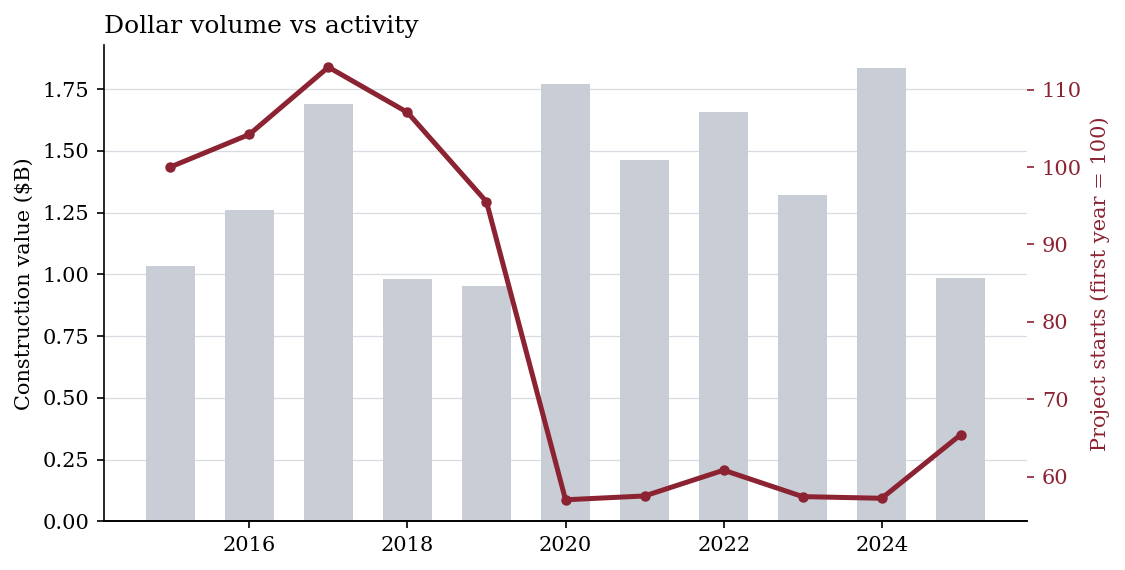

In [ ]:
#### CELL 6 — charts ############################################################

MAROON, GREY, LIGHT = "#8C2332", "#9aa3af", "#d8dce2"
plt.rcParams.update({"font.family": "serif", "figure.facecolor": "white"})

def style(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=LIGHT, lw=.6)
    ax.set_axisbelow(True)

yrs = annual.index.values

fig, ax = plt.subplots(figsize=(7.6, 3.9), dpi=150)
ax.plot(yrs, annual["permits"], color=GREY, lw=2, marker="o", ms=4,
        label="All permits")
ax.plot(yrs, annual["comm_permits"], color=MAROON, lw=2.4, marker="o", ms=4,
        label="Business & mixed use")
style(ax); ax.set_ylim(0, None); ax.legend(frameon=False)
ax.set_title("Permits filed per year, Orleans Parish", loc="left")
plt.tight_layout(); plt.savefig("chart_permits.png"); plt.show()

fig, ax = plt.subplots(figsize=(7.6, 3.9), dpi=150)
ax.bar(yrs, annual["comm_projects"], color=MAROON, width=.62)
for y, v in zip(yrs, annual["comm_projects"]):
    ax.text(y, v * 1.02, f"{v:,}", ha="center", fontsize=8.5)
style(ax); ax.set_ylim(0, annual["comm_projects"].max() * 1.15)
ax.set_title("Commercial project starts per year", loc="left")
plt.tight_layout(); plt.savefig("chart_projects.png"); plt.show()

fig, ax = plt.subplots(figsize=(7.6, 3.9), dpi=150)
ax.bar(yrs, annual["value"] / 1e9, color="#c9ced6", width=.62)
ax2 = ax.twinx()
ax2.plot(yrs, annual["projects"] / annual["projects"].iloc[0] * 100,
         color=MAROON, lw=2.4, marker="o", ms=4)
style(ax); ax2.spines[["top", "right", "left"]].set_visible(False)
ax.set_ylabel("Construction value ($B)")
ax2.set_ylabel("Project starts (first year = 100)", color=MAROON)
ax2.tick_params(colors=MAROON)
ax.set_title("Dollar volume vs activity", loc="left")
plt.tight_layout(); plt.savefig("chart_value.png"); plt.show()

In [ ]:
#### CELL 6a — build and normalize the neighborhood field #######################

# Quirk 1: comma-concatenated names. Take the first, trim whitespace.
df["hood"] = df["Subdivision"].astype(str).str.split(",").str[0].str.strip()
df.loc[df["Subdivision"].isna(), "hood"] = "(unassigned)"

# Quirk 2: hand-typed spelling variants folded into canonical names.
# Each was checked against the permit address before being mapped here.
HOOD_FIXES = {
    "Bayou St. John":     "Bayou St John",
    "St. Claude":         "St Claude",
    "St. Roch":           "St Roch",
    "Treme":              "Treme - Lafitte",
    "Faubourg Marigny":   "Marigny",                    # Touro/Esplanade/Burgundy
    "Warehouse District": "Central Business District",  # 451 Girod St, CBD-6
    "Lafayette Square":   "Central Business District",  # 730 Julia St, CBD-5
    "Carrollton":         "Leonidas",                   # 6201 S Claiborne, HU-B1
}
before = df["hood"].nunique()
df["hood"] = df["hood"].replace(HOOD_FIXES)
print(f"neighborhood names: {before} -> {df['hood'].nunique()} after normalizing")
print(f"unassigned rows: {(df['hood'] == '(unassigned)').sum():,}"
      f" ({(df['hood'] == '(unassigned)').mean() * 100:.1f}%)")

# Sanity check: anything left with very few permits is either a genuine small
# neighborhood or a variant not yet caught. Check on rerun.
rare = df["hood"].value_counts()
rare = rare[rare < 20]
if len(rare):
    print("\nneighborhoods with under 20 permits (check for further variants):")
    print(rare.to_string())
else:
    print("\nno remaining low-count names")

# rebuild `full` so it carries the new column
full = df[(df["yr"] >= FIRST_FULL_YEAR) & (df["yr"] <= LAST_FULL_YEAR)]
comm = full[full["comm"]]

neighborhood names: 95 -> 87 after normalizing
unassigned rows: 60,588 (17.7%)

neighborhoods with under 20 permits (check for further variants):
hood
Lakeshore                   1
Irish Byu                   1
Designated - New Orelans    1
Mcdonogh                    1


In [ ]:
#### CELL 6b — before/after comparison by neighborhood ##########################
# Compares the pre-COVID period against the settled recent period.
# 2020 and 2021 are deliberately skipped: they are the transition, not a
# stable baseline on either side.

PRE_YEARS  = (2015, 2019)
POST_YEARS = (2022, 2025)
MIN_PRE_PERMITS = 90      # total across the whole pre period, not per year

pre  = comm[comm["yr"].between(*PRE_YEARS)]
post = comm[comm["yr"].between(*POST_YEARS)]

hood = pd.DataFrame({
    "permits_pre":  pre.groupby("hood").size(),
    "permits_post": post.groupby("hood").size(),
    "value_pre":    pre.groupby("hood")["val_counted"].sum(),
    "value_post":   post.groupby("hood")["val_counted"].sum(),
}).fillna(0)

# convert to annual averages so the different period lengths compare fairly
n_pre  = PRE_YEARS[1]  - PRE_YEARS[0]  + 1
n_post = POST_YEARS[1] - POST_YEARS[0] + 1
# permits_* and value_* above are PERIOD TOTALS (4 years pre, 4 years post).
# The annual_* columns below divide by the period length so the two eras
# compare fairly. Always chart or quote the annual_* figures, never the totals.
hood["annual_pre"]        = hood["permits_pre"]  / n_pre
hood["annual_post"]       = hood["permits_post"] / n_post
hood["annual_value_pre"]  = hood["value_pre"]    / n_pre
hood["annual_value_post"] = hood["value_post"]   / n_post
hood["pct_change"]        = (hood["annual_post"] / hood["annual_pre"] - 1) * 100
hood["value_pct_change"]  = np.where(hood["annual_value_pre"] > 0,
    (hood["annual_value_post"] / hood["annual_value_pre"] - 1) * 100, np.nan)

hood = hood[hood["permits_pre"] >= MIN_PRE_PERMITS]
hood = hood.drop(index="(unassigned)", errors="ignore")
print(f"{len(hood)} neighborhoods with enough volume to compare\n")

print("LARGEST COMMERCIAL MARKETS, annual average permits")
display(hood.sort_values("annual_post", ascending=False)
            .head(20)[["annual_pre", "annual_post", "pct_change"]].round(1))

print("\nHELD UP BEST")
display(hood.sort_values("pct_change", ascending=False)
            .head(10)[["annual_pre", "annual_post", "pct_change"]].round(1))

print("\nFELL FURTHEST")
display(hood.sort_values("pct_change")
            .head(10)[["annual_pre", "annual_post", "pct_change"]].round(1))

print("\nCONSTRUCTION VALUE PER YEAR, $M — same neighborhoods, largest first")
print("(value is far lumpier than permit counts; see the single-project check below)")
vt = hood.sort_values("annual_post", ascending=False).head(15).copy()
vt["val_pre_$M"]  = (vt["annual_value_pre"]  / 1e6).round(1)
vt["val_post_$M"] = (vt["annual_value_post"] / 1e6).round(1)
display(vt[["val_pre_$M", "val_post_$M", "value_pct_change"]].round(1))


55 neighborhoods with enough volume to compare

LARGEST COMMERCIAL MARKETS, annual average permits


,annual_pre,annual_post,pct_change
hood,,,
Central Business District,1207.4,409.8,-66.1
French Quarter,416.0,276.0,-33.7
Lower Garden District,223.6,178.2,-20.3
Central City,339.2,166.2,-51.0
Mid-City,322.8,127.5,-60.5
Audubon,168.6,117.0,-30.6
Gert Town,94.8,83.2,-12.2
Seventh Ward,214.0,81.8,-61.8
Tulane - Gravier,121.4,69.0,-43.2



HELD UP BEST


,annual_pre,annual_post,pct_change
hood,,,
Lake Terrace & Oaks,20.6,22.8,10.4
St Thomas Dev,29.8,26.8,-10.2
Gert Town,94.8,83.2,-12.2
East Carrollton,34.4,29.5,-14.2
Lower Garden District,223.6,178.2,-20.3
Fairgrounds,55.2,42.2,-23.5
Lower Ninth Ward,42.8,31.8,-25.8
Algiers Point,25.2,18.2,-27.6
Garden District,34.0,24.5,-27.9



FELL FURTHEST


,annual_pre,annual_post,pct_change
hood,,,
Plum Orchard,83.0,7.8,-90.7
Navarre,63.4,6.2,-90.1
West End,49.8,9.5,-80.9
Lakeview,92.4,21.2,-77.0
City Park,41.2,10.5,-74.5
St Claude,143.4,43.2,-69.8
West Lake Forest,73.0,23.2,-68.2
Bayou St John,60.8,19.8,-67.5
Behrman,83.2,27.5,-66.9



CONSTRUCTION VALUE PER YEAR, $M — same neighborhoods, largest first
(value is far lumpier than permit counts; see the single-project check below)


,val_pre_$M,val_post_$M,value_pct_change
hood,,,
Central Business District,284.9,222.2,-22.0
French Quarter,45.9,56.8,23.8
Lower Garden District,45.6,88.5,94.4
Central City,13.2,28.7,118.3
Mid-City,31.4,36.9,17.6
Audubon,25.3,96.0,279.3
Gert Town,6.2,43.8,608.5
Seventh Ward,5.7,47.4,732.2
Tulane - Gravier,16.2,11.1,-31.4


In [ ]:
#### CELL 6c — value concentration ##############################################
# Which neighborhoods hold the construction dollars, and how concentrated.
# WATCH FOR: a small neighborhood with a huge value is usually one big
# project. The permit count is the safer measure
# at this geography. The check below flags them.

recent = comm[comm["yr"].between(*POST_YEARS)]
val = recent.groupby("hood")["val_counted"].sum().sort_values(ascending=False)

print(f"top 10 neighborhoods = {val.head(10).sum() / val.sum() * 100:.0f}%"
      f" of commercial construction value, {POST_YEARS[0]}–{POST_YEARS[1]}\n")
display((val.head(12) / 1e6).round(1).rename("value_$M"))

print("\nSINGLE-PROJECT CHECK — largest permit as a share of the neighborhood total")
for h in val.head(12).index:
    sub = recent[recent["hood"] == h]
    if sub["val_counted"].sum() == 0:
        continue
    share = sub["val_counted"].max() / sub["val_counted"].sum() * 100
    flag = "  <-- one project dominates, do not report as a market" if share > 50 else ""
    print(f"  {h:28s} {share:5.1f}%{flag}")

top 10 neighborhoods = 78% of commercial construction value, 2022–2025



,value_$M
hood,
Central Business District,889.0
Dillard,397.7
Audubon,384.0
Lower Garden District,354.2
French Quarter,227.3
Seventh Ward,189.4
Gert Town,175.3
Mid-City,147.6
Lakeview,139.0



SINGLE-PROJECT CHECK — largest permit as a share of the neighborhood total
  Central Business District     10.2%
  Dillard                       90.6%  <-- one project dominates, do not report as a market
  Audubon                       13.0%
  Lower Garden District         19.7%
  French Quarter                14.9%
  Seventh Ward                  80.7%  <-- one project dominates, do not report as a market
  Gert Town                     46.1%
  Mid-City                      60.1%  <-- one project dominates, do not report as a market
  Lakeview                      95.9%  <-- one project dominates, do not report as a market
  Bywater                       89.3%  <-- one project dominates, do not report as a market
  Central City                  18.9%
  Lake Terrace & Oaks           33.3%


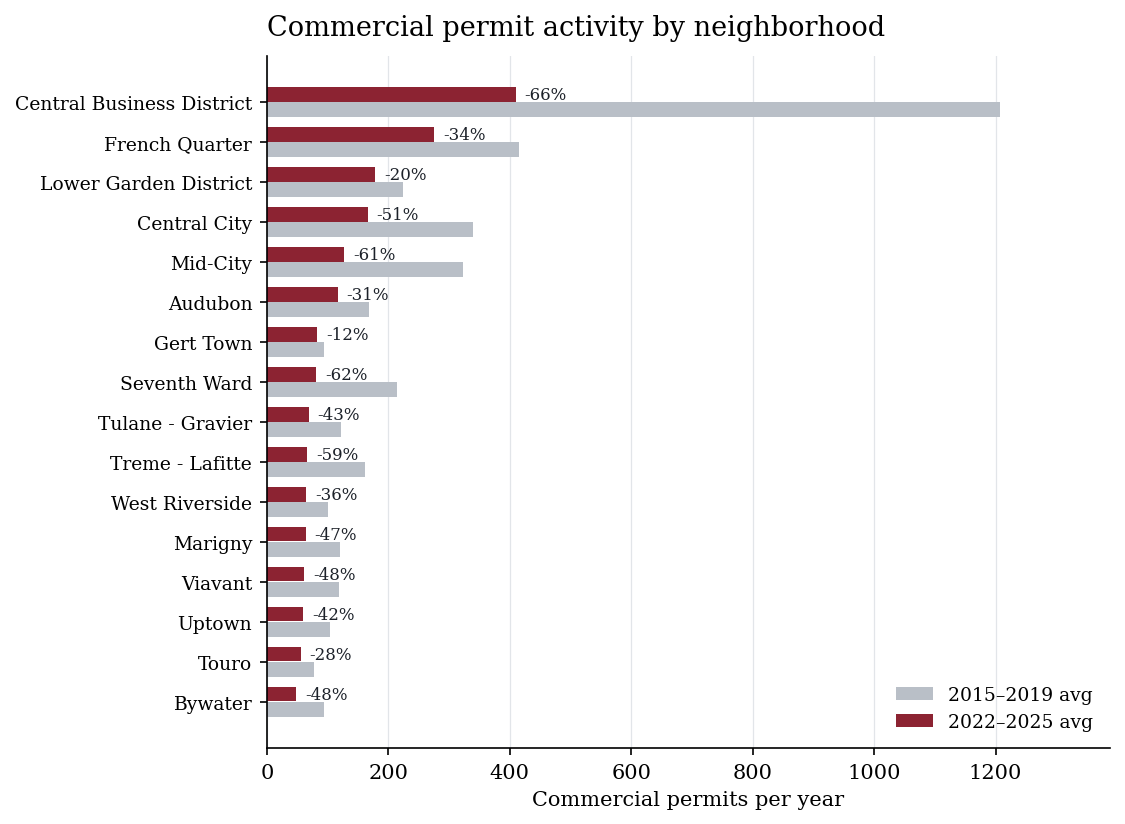

In [ ]:
#### CELL 6d — neighborhood chart ###############################################

MAROON, GREY, INK = "#8C2332", "#b9bfc7", "#1c2129"
N_SHOW = 16

t = hood.sort_values("annual_post", ascending=False).head(N_SHOW)
t = t.sort_values("annual_post")   # smallest at bottom for the horizontal bars

fig, ax = plt.subplots(figsize=(7.6, 5.6), dpi=150)
y = np.arange(len(t))
ax.barh(y - 0.19, t["annual_pre"],  height=.36, color=GREY,
        label=f"{PRE_YEARS[0]}–{PRE_YEARS[1]} avg")
ax.barh(y + 0.19, t["annual_post"], height=.36, color=MAROON,
        label=f"{POST_YEARS[0]}–{POST_YEARS[1]} avg")
ax.set_yticks(y); ax.set_yticklabels(t.index, fontsize=9)
for i, (p, c) in enumerate(zip(t["annual_post"], t["pct_change"])):
    ax.text(p + t["annual_pre"].max() * 0.012, i + 0.19,
            f"{c:+.0f}%", va="center", fontsize=8, color=INK)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e2e5e9", lw=.6); ax.set_axisbelow(True)
ax.set_xlim(0, t["annual_pre"].max() * 1.15)
ax.set_xlabel("Commercial permits per year", fontsize=10)
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title("Commercial permit activity by neighborhood", loc="left", fontsize=13, pad=10)
plt.tight_layout(); plt.savefig("chart_neighborhood.png"); plt.show()

hood.to_csv("neighborhood_summary.csv")

In [ ]:
#### CELL 6f — does decline track distance from the CBD? ########################
# Uses the Location 1 coordinates already in the raw file. Neighborhood
# centroids are medians, which resist a few bad geocodes.

ll = df["Location 1"].astype(str).str.strip("()").str.split(",", expand=True)
df["lat"] = pd.to_numeric(ll[0], errors="coerce")
df["lon"] = pd.to_numeric(ll[1], errors="coerce")

# Orleans Parish bounding box drops the occasional phantom geocode
inbox = df["lat"].between(29.85, 30.20) & df["lon"].between(-90.20, -89.60)
cent = df[inbox].groupby("hood")[["lat", "lon"]].median()

CBD = cent.loc["Central Business District"]
miles = np.sqrt(((cent["lat"] - CBD["lat"]) * 69) ** 2 +
                ((cent["lon"] - CBD["lon"]) * 69 *
                 np.cos(np.radians(29.95))) ** 2)
hood["miles_from_cbd"] = miles

test = hood.dropna(subset=["miles_from_cbd", "pct_change"])
r  = st.pearsonr(test["miles_from_cbd"], test["pct_change"])
sp = st.spearmanr(test["miles_from_cbd"], test["pct_change"])

print("DOES DISTANCE FROM THE CBD EXPLAIN THE DECLINE?")
print(f"  Pearson  r={r.statistic:+.3f}  p={r.pvalue:.4f}")
print(f"  Spearman r={sp.statistic:+.3f}  p={sp.pvalue:.4f}   (n={len(test)})")
verdict = ("YES — a geographic framing is defensible" if r.pvalue < 0.05
           else "NO — do not describe this as a core-vs-periphery pattern")
print(f"  -> {verdict}\n")

bands = pd.cut(test["miles_from_cbd"], [0, 2, 4, 6, 25],
               labels=["<2 mi", "2–4 mi", "4–6 mi", "6+ mi"])
display(test.groupby(bands, observed=True)
            .agg(neighborhoods=("pct_change", "size"),
                 mean_change=("pct_change", "mean")).round(1))

print("\nadjacent neighborhoods often diverge — a few of the widest gaps:")
near = test.nsmallest(6, "miles_from_cbd")[["miles_from_cbd", "pct_change"]]
display(near.round(1))

DOES DISTANCE FROM THE CBD EXPLAIN THE DECLINE?
  Pearson  r=-0.120  p=0.3810
  Spearman r=-0.139  p=0.3111   (n=55)
  -> NO — do not describe this as a core-vs-periphery pattern



,neighborhoods,mean_change
miles_from_cbd,,
<2 mi,16,-47.7
2–4 mi,25,-48.8
4–6 mi,7,-50.3
6+ mi,6,-59.6



adjacent neighborhoods often diverge — a few of the widest gaps:


,miles_from_cbd,pct_change
hood,,
Central Business District,0.0,-66.1
French Quarter,0.7,-33.7
Central City,1.1,-51.0
Lower Garden District,1.1,-20.3
Tulane - Gravier,1.1,-43.2
Treme - Lafitte,1.3,-59.1


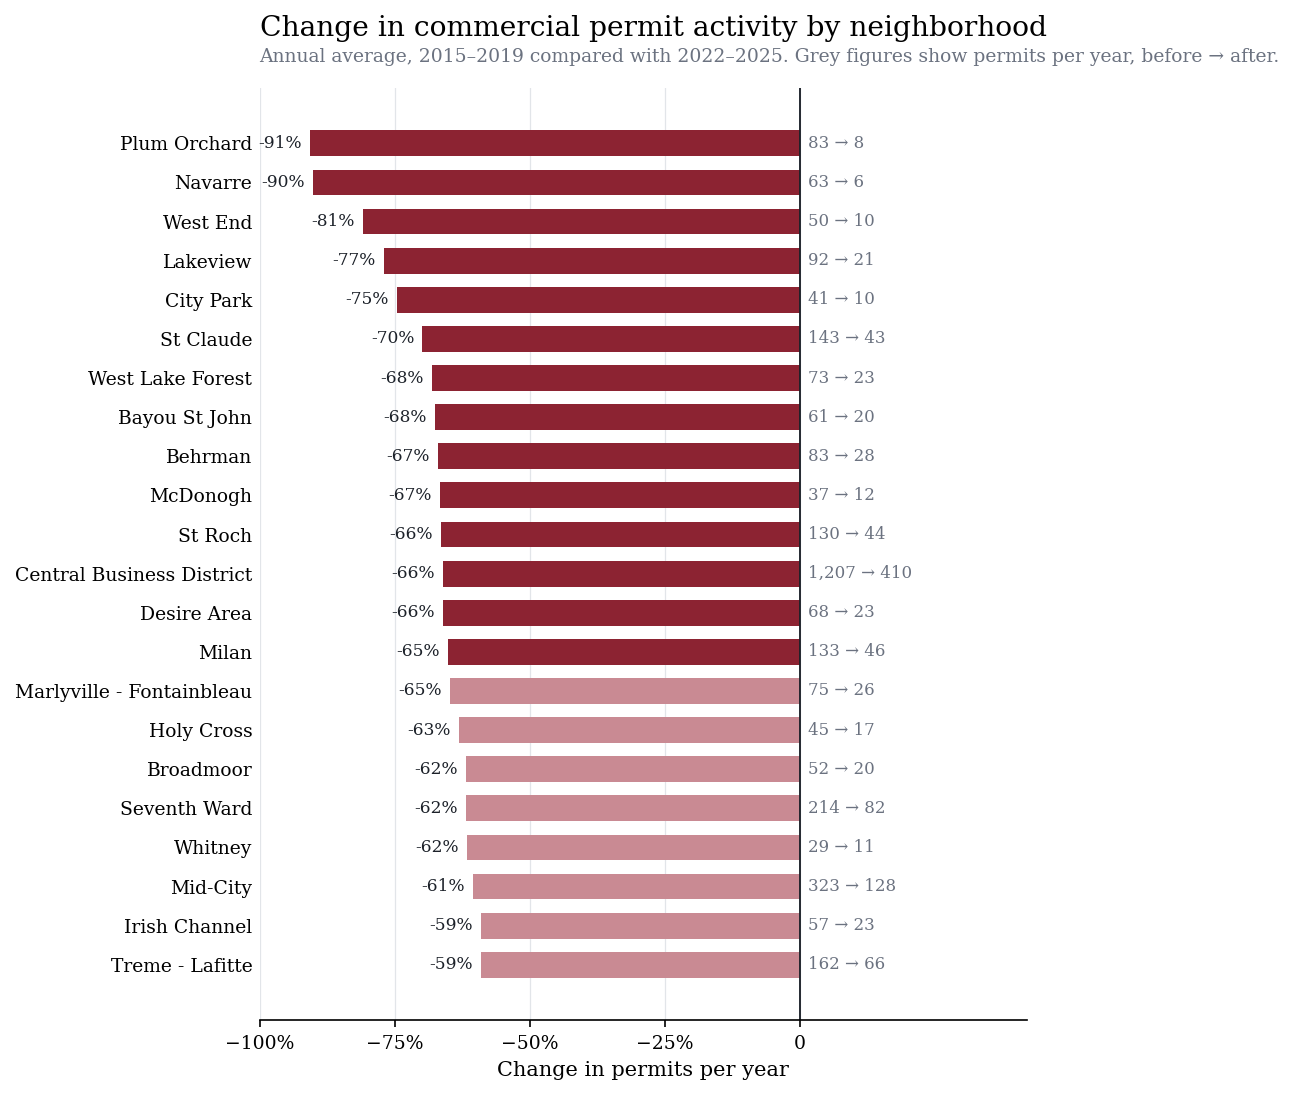

In [ ]:
#### CELL 6g — chart: steepest drops #########################################

MAROON, MID, GREY, INK, LIGHT = "#8C2332", "#c98a93", "#9aa3af", "#1c2129", "#e2e5e9"
N_WORST = 22

sel = hood.sort_values("pct_change").head(N_WORST).iloc[::-1]

fig, ax = plt.subplots(figsize=(7.8, 7.4), dpi=150)
y = np.arange(len(sel))
# shade by severity, NOT by geography — colour should not imply a spatial story
cols = [MAROON if c <= -65 else (MID if c <= -45 else GREY)
        for c in sel["pct_change"]]
ax.barh(y, sel["pct_change"], color=cols, height=.66)

for i, (ch, a, b) in enumerate(zip(sel["pct_change"],
                                   sel["annual_pre"], sel["annual_post"])):
    ax.text(ch - 1.5, i, f"{ch:.0f}%", va="center", ha="right",
            fontsize=8.2, color=INK)
    ax.text(1.5, i, f"{a:,.0f} → {b:,.0f}", va="center", ha="left",
            fontsize=8, color="#6b7280")

ax.set_yticks(y); ax.set_yticklabels(sel.index, fontsize=9)
ax.set_xlim(-100, 42); ax.axvline(0, color=INK, lw=.9)
ax.set_xticks([-100, -75, -50, -25, 0])
ax.set_xticklabels(["−100%", "−75%", "−50%", "−25%", "0"], fontsize=9)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", color=LIGHT, lw=.6); ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
ax.set_title("Change in commercial permit activity by neighborhood",
             loc="left", fontsize=13.5, pad=25)
ax.text(0, 1.028, f"Annual average, {PRE_YEARS[0]}–{PRE_YEARS[1]} compared with "
        f"{POST_YEARS[0]}–{POST_YEARS[1]}. Grey figures show permits per year, "
        "before → after.",
        transform=ax.transAxes, fontsize=9, color="#6b7280")
ax.set_xlabel("Change in permits per year", fontsize=10)
plt.tight_layout(); plt.savefig("chart_decline_by_hood.png", bbox_inches="tight")
plt.show()

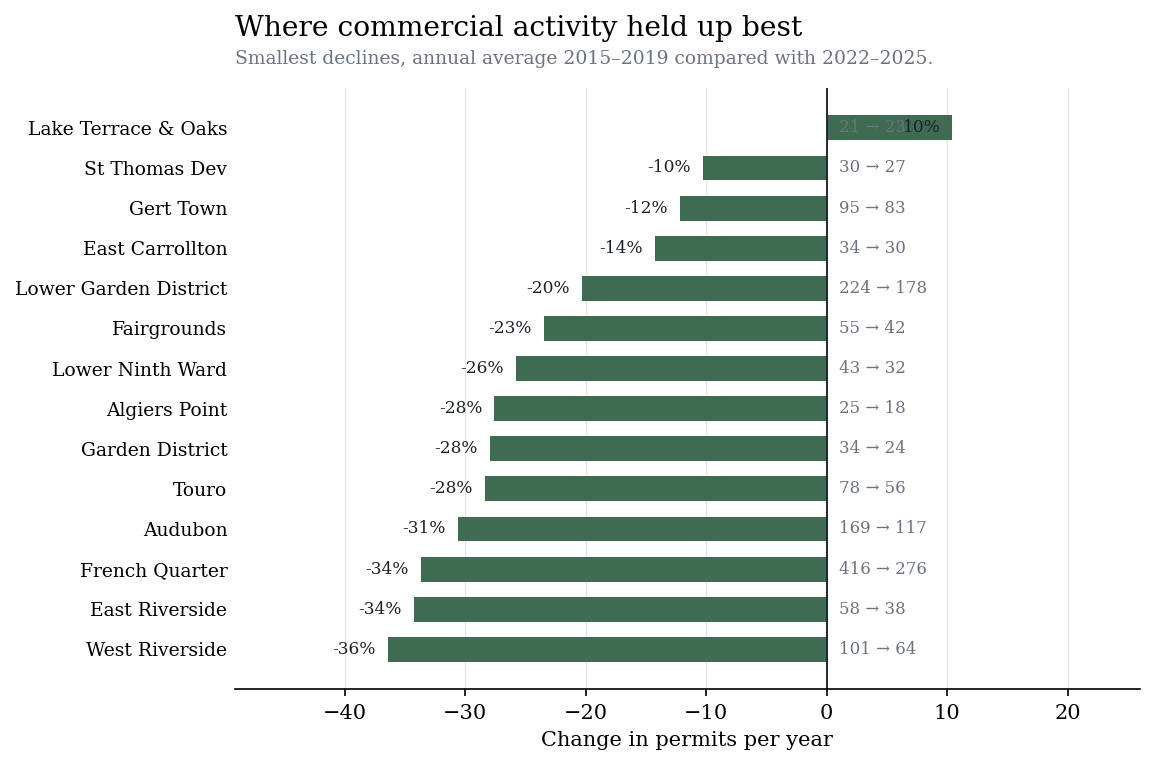

widest gap: 10% to -91% across 55 neighborhoods with comparable volume


In [ ]:
#### CELL 6h — chart: neighborhoods that held up best ###########################
# Pair this with 6g to offset decline-only

GREEN = "#3f6b52"
N_BEST = 14

best = hood.sort_values("pct_change", ascending=False).head(N_BEST).iloc[::-1]

fig, ax = plt.subplots(figsize=(7.8, 5.2), dpi=150)
y = np.arange(len(best))
ax.barh(y, best["pct_change"], color=GREEN, height=.62)

for i, (ch, a, b) in enumerate(zip(best["pct_change"],
                                   best["annual_pre"], best["annual_post"])):
    ax.text(ch - 1.0, i, f"{ch:.0f}%", va="center", ha="right",
            fontsize=8.2, color=INK)
    ax.text(1.0, i, f"{a:,.0f} → {b:,.0f}", va="center", ha="left",
            fontsize=8, color="#6b7280")

ax.set_yticks(y); ax.set_yticklabels(best.index, fontsize=9)
ax.set_xlim(best["pct_change"].min() * 1.35, 26); ax.axvline(0, color=INK, lw=.9)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", color=LIGHT, lw=.6); ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
ax.set_title("Where commercial activity held up best", loc="left",
             fontsize=13.5, pad=25)
ax.text(0, 1.04, f"Smallest declines, annual average {PRE_YEARS[0]}–{PRE_YEARS[1]} "
        f"compared with {POST_YEARS[0]}–{POST_YEARS[1]}.",
        transform=ax.transAxes, fontsize=9, color="#6b7280")
ax.set_xlabel("Change in permits per year", fontsize=10)
plt.tight_layout(); plt.savefig("chart_held_up_best.png", bbox_inches="tight")
plt.show()

# the spread between best and worst
print(f"widest gap: {hood['pct_change'].max():.0f}% to "
      f"{hood['pct_change'].min():.0f}% across "
      f"{len(hood)} neighborhoods with comparable volume")

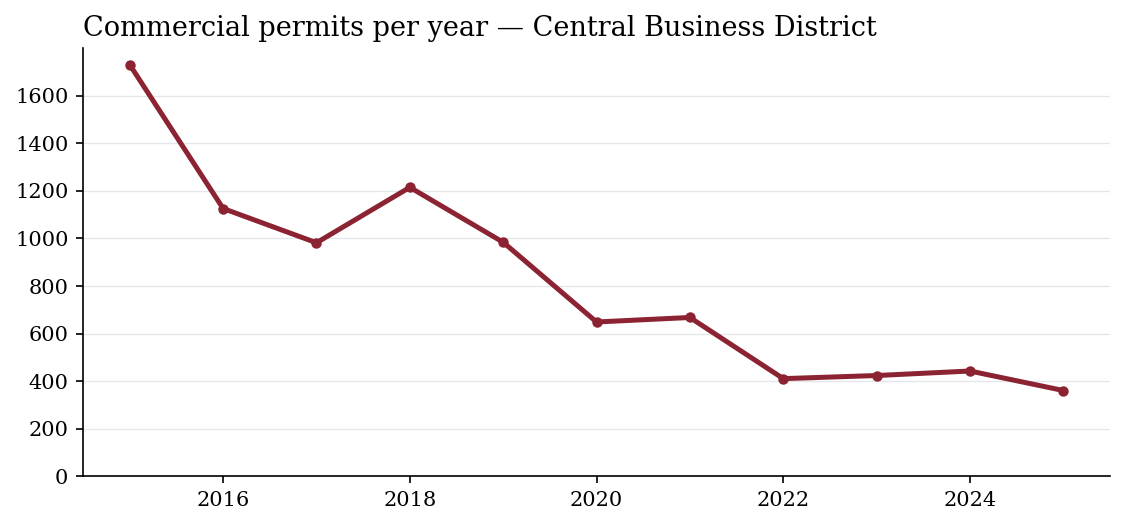

,permits,value
yr,,
2015,1730,"$281,151,933"
2016,1126,"$270,394,520"
2017,982,"$532,478,876"
2018,1215,"$143,257,366"
2019,984,"$197,214,705"
2020,649,"$142,473,406"
2021,668,"$331,076,151"
2022,411,"$310,224,443"
2023,424,"$211,731,475"


In [ ]:
#### CELL 6e — optional: one neighborhood over time #############################
# Change PICK to any neighborhood name from the tables above.

PICK = "Central Business District"

series = (comm[comm["hood"] == PICK].groupby("yr")
          .agg(permits=("fd", "size"), value=("val_counted", "sum")))

fig, ax = plt.subplots(figsize=(7.6, 3.6), dpi=150)
ax.plot(series.index, series["permits"], color=MAROON, lw=2.4, marker="o", ms=4)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e2e5e9", lw=.6); ax.set_axisbelow(True)
ax.set_ylim(0, None)
ax.set_title(f"Commercial permits per year — {PICK}", loc="left", fontsize=13)
plt.tight_layout(); plt.show()

display(series.assign(value=lambda d: d["value"].map("${:,.0f}".format)))

68 neighborhoods with enough volume, sorted by rise in concentration



,Neighborhood,Conc. pre,Conc. post,Change,Post total $,Largest permit $,Largest permit owner
0,Lakeview,26%,96%,+70 pts,$139.0M,$133.3M,Mt Carmel Academy of New Orleans Inc
1,Dillard,30%,91%,+60 pts,$397.7M,$360.3M,Dillard University
2,Seventh Ward,26%,81%,+54 pts,$189.4M,$152.8M,Orleans Parish School Board
3,Bywater,39%,89%,+50 pts,$138.2M,$123.4M,The City Of New Orleans
4,Algiers Point,38%,86%,+49 pts,$10.5M,$9.0M,"The City Of New Orleans, State Of Louisiana-Ccc"
...,...,...,...,...,...,...,...
63,Gentilly Terrace,56%,17%,-38 pts,$2.7M,$0.5M,The Kronlage Fmlylimited
64,St Claude,69%,22%,-48 pts,$7.0M,$1.5M,Bywater Development LLC
65,(unassigned),67%,16%,-51 pts,$1.5M,$0.2M,(no owner recorded)
66,Lakeshore - Lake Vista,86%,30%,-56 pts,$7.3M,$2.2M,"RCR Theater Venture LLC, Corchiani Properties LLC"


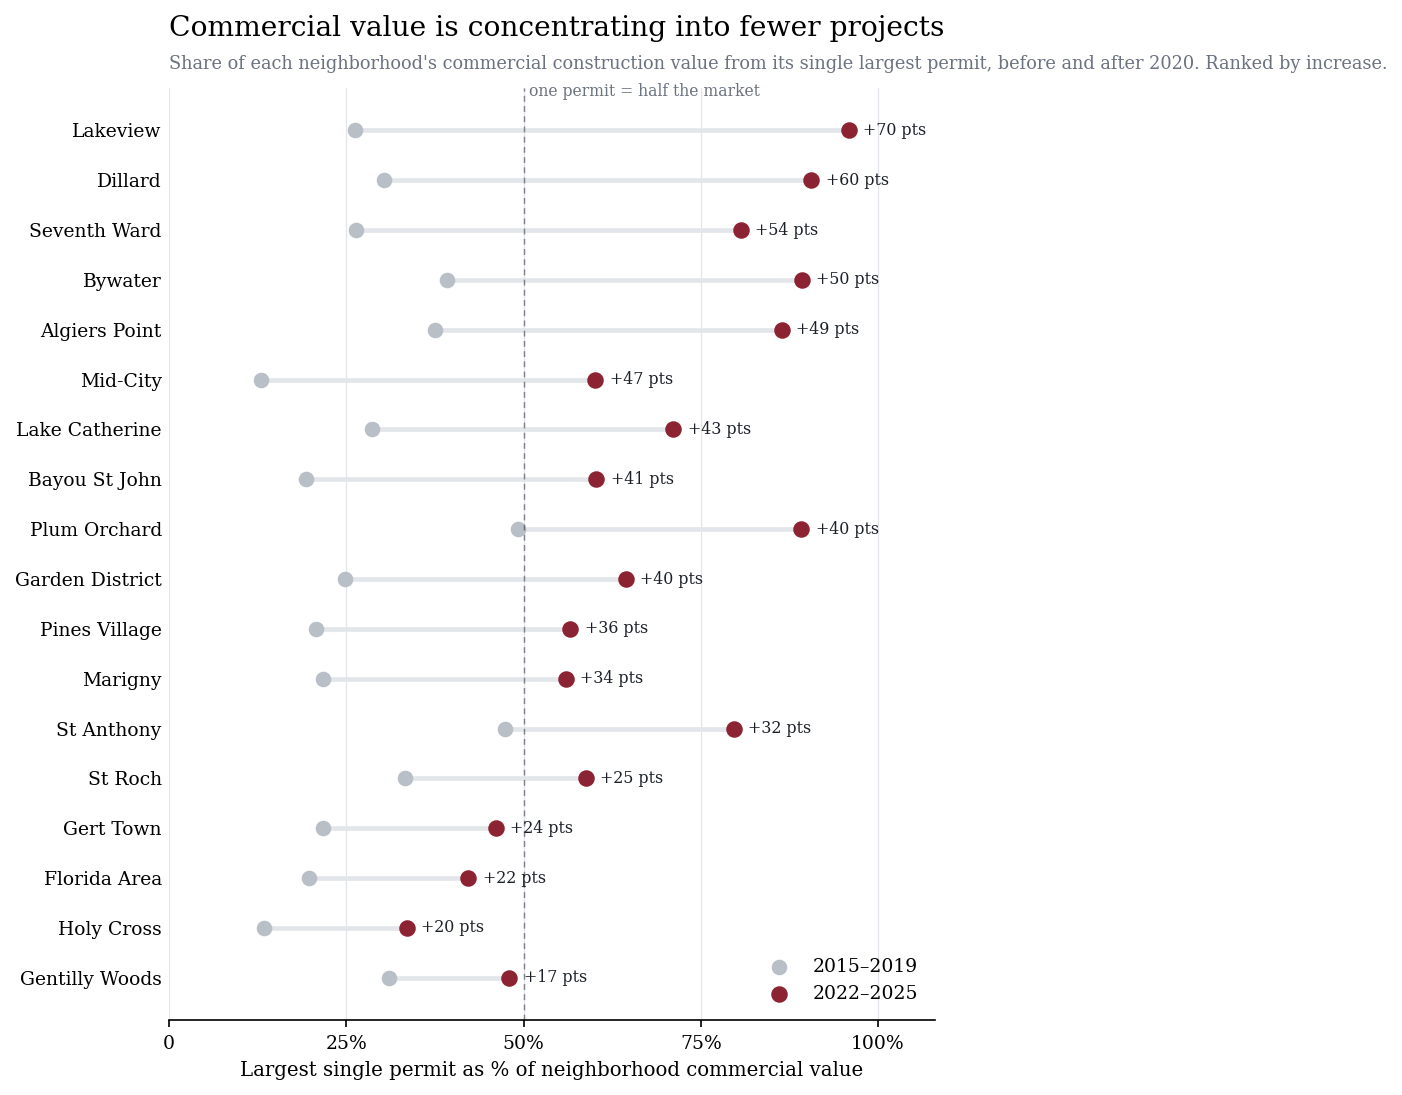

In [ ]:
# WHAT "CONCENTRATION" MEANS
#   The share of a neighborhood's commercial construction value that comes from
#   its single largest permit. A high number means one project dominates; the
#   neighborhood is not really a broad "market" that period. Watching this rise
#   from pre to post is the clearest evidence of the shift toward fewer, larger,
#   projects.
#
# INTERNAL USE
#   This table names property owners. That is public record and fine for
#   internal analysis, but not advised for publication.
# =============================================================================

#### CELL 6i — concentration table + chart ######################################

# needs Owner from the raw file; merge it in if it's not already on df
if "Owner" not in df.columns:
    raise RuntimeError("df has no Owner column — re-run the load cell (CELL 3).")

PRE, POST = (2015, 2019), (2022, 2025)
MIN_PRE_COMMERCIAL = 30   # commercial permits in the pre period to be included

c = df[df["comm"]].copy()

def concentration(sub):
    tot = sub.groupby("hood")["val_counted"].sum()
    idx = sub.groupby("hood")["val_counted"].idxmax()      # row of the biggest permit
    top = sub.loc[idx, ["hood", "val_counted", "Owner"]].set_index("hood")
    out = pd.DataFrame({"total": tot,
                        "top_val": top["val_counted"],
                        "top_owner": top["Owner"]})
    out["conc"] = np.where(out["total"] > 0, out["top_val"] / out["total"] * 100, np.nan)
    return out

pre  = concentration(c[c["yr"].between(*PRE)])
post = concentration(c[c["yr"].between(*POST)])

vol = c[c["yr"].between(*PRE)].groupby("hood").size()
keep = vol[vol >= MIN_PRE_COMMERCIAL].index

tbl = pd.DataFrame(index=keep)
tbl["conc_pre"]   = pre["conc"]
tbl["conc_post"]  = post["conc"]
tbl["total_post"] = post["total"]
tbl["top_val"]    = post["top_val"]
tbl["owner"]      = post["top_owner"]
tbl["conc_change"] = tbl["conc_post"] - tbl["conc_pre"]
tbl = tbl.dropna(subset=["conc_pre", "conc_post"]).sort_values("conc_change", ascending=False)

# ---- readable table ----
show = pd.DataFrame({
    "Neighborhood":  tbl.index,
    "Conc. pre":     tbl["conc_pre"].round(0).astype(int).astype(str) + "%",
    "Conc. post":    tbl["conc_post"].round(0).astype(int).astype(str) + "%",
    "Change":        tbl["conc_change"].round(0).astype(int).map(lambda v: f"+{v}" if v >= 0 else str(v)) + " pts",
    "Post total $":  tbl["total_post"].map(lambda v: f"${v/1e6:.1f}M"),
    "Largest permit $": tbl["top_val"].map(lambda v: f"${v/1e6:.1f}M"),
    "Largest permit owner": tbl["owner"].fillna("(no owner recorded)"),
}).reset_index(drop=True)

print(f"{len(show)} neighborhoods with enough volume, sorted by rise in concentration\n")
display(show)
tbl.to_csv("concentration.csv")

# ---- dumbbell chart ----
MAROON, GREY, INK, LIGHT = "#8C2332", "#b9bfc7", "#1c2129", "#e2e5e9"
N = 18
sel = tbl.head(N).iloc[::-1]

fig, ax = plt.subplots(figsize=(8.2, 7.4), dpi=150)
y = np.arange(len(sel))
for i, (a, b) in enumerate(zip(sel["conc_pre"], sel["conc_post"])):
    ax.plot([a, b], [i, i], color=LIGHT, lw=2.2, zorder=1)
ax.scatter(sel["conc_pre"],  y, color=GREY,   s=42, zorder=2, label=f"{PRE[0]}–{PRE[1]}")
ax.scatter(sel["conc_post"], y, color=MAROON, s=48, zorder=3, label=f"{POST[0]}–{POST[1]}")
for i, (b, ch) in enumerate(zip(sel["conc_post"], sel["conc_change"])):
    ax.text(b + 2, i, f"+{ch:.0f} pts", va="center", fontsize=7.6, color=INK)
ax.set_yticks(y); ax.set_yticklabels(sel.index, fontsize=9)
ax.set_xlim(0, 108)
ax.set_xticks([0, 25, 50, 75, 100]); ax.set_xticklabels(["0", "25%", "50%", "75%", "100%"], fontsize=9)
ax.axvline(50, color=INK, lw=.7, ls=(0, (4, 3)), alpha=.5)
ax.text(50, len(sel) - 0.3, " one permit = half the market", fontsize=7.5, color="#6b7280")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", color=LIGHT, lw=.6); ax.set_axisbelow(True); ax.tick_params(axis="y", length=0)
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_xlabel("Largest single permit as % of neighborhood commercial value", fontsize=9.5)
ax.set_title("Commercial value is concentrating into fewer projects", loc="left", fontsize=13.5, pad=25)
ax.text(0, 1.02, "Share of each neighborhood's commercial construction value from its single "
        "largest permit, before and after 2020. Ranked by increase.",
        transform=ax.transAxes, fontsize=8.5, color="#6b7280")
plt.tight_layout(); plt.savefig("chart_concentration.png", bbox_inches="tight"); plt.show()



PROJECT STARTS PER YEAR BY OWNER CATEGORY   (172,015 projects)
2020–21 excluded as the transition period



,2015–2019,2022–2025,change
category,,,
Private / other,20286.2,11257.5,-45%
Churches / religious,88.2,97.8,+11%
City government,34.2,74.5,+118%
Housing Authority,2.4,69.8,+2806%
Universities,25.6,52.0,+103%
Finance Authority,0.0,42.2,new
Redevelopment Authority,57.2,32.2,-44%
Schools K-12,44.8,29.5,-34%
Public-private partnership,16.0,17.5,+9%



=== PRIVATE v PUBLIC ===
  Private / other:          20,286 ->   11,258 per year  (-44.5%)
  Institutional + public:      308 ->      452 per year  (+47.0%)

  Institutional share of project starts: 1.5% -> 3.9%


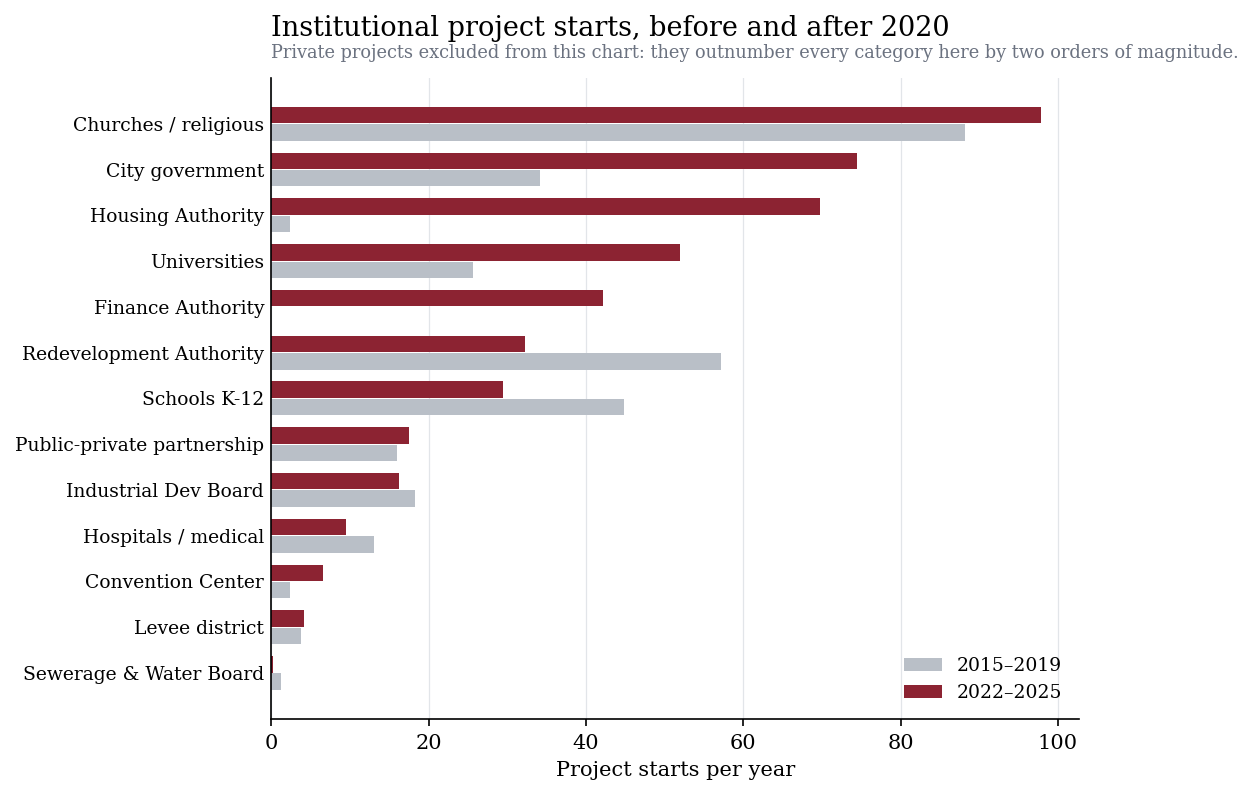

In [ ]:
# =============================================================================
# Permit owner classification, project starts before and after 2020
# WHAT THIS DOES
#   Classifies permit owners into categories, counts distinct
#   PROJECTS (not permits) in each category, and compares annual averages for
#   2015-2019 against 2022-2025.
#
# WHY PROJECTS AND NOT PERMITS
#   A single development files dozens or hundreds of permits, so permit counts
#   measure filing behavior as much as building activity. The Industrial
#   Development Board looks like the top institutional filer by permits and
#   drops to mid-pack by projects. Projects is the preferred number to report.
#
# WHY THE CLASSIFIER NEEDS A FALSE-MATCH LIST
#   Plain keyword matching produces false matches i.e. "college" catches Ye
#   Olde College Inn, a restaurant. "church" catches Church's Fried Chicken and
#   the surnames Newchurch and Upchurch. "tulane" and "loyola" catch dozens of
#   address LLCs on Tulane Avenue and Loyola Street that have nothing to do
#   with either university. "parish" catches a person named Stephen Parish.
#   Every one of these was found by reading the actual owner list, not by
#   guessing. Add to FALSE_MATCH as more found.
#
# WHY PUBLIC-PRIVATE PARTNERSHIP IS ITS OWN CATEGORY
#   Deals like the Finance Authority / AG 2018 affordable housing development
#   and the City / Harrah's casino renovation name both a government financing
#   entity and a private developer. Forcing them into "government" overstates
#   public construction; forcing them into "private" hides the public role.
# =============================================================================


#### CELL O1 — owner classification + project comparison ########################

import numpy as np, pandas as pd

PRE_YEARS  = (2015, 2019)     # 5-year baseline
POST_YEARS = (2022, 2025)     # 2020-21 excluded as the transition

d = df[~df["CurrentStatus"].astype(str).str.upper().str.startswith("VOIDED")].copy()
if "fd" not in d.columns:
    d["fd"] = pd.to_datetime(d["FilingDate"], errors="coerce", format="mixed")
df["yr"] = df["fd"].dt.year.astype("Int64")
own = d["Owner"].astype(str)

import warnings

def has(pattern):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        return own.str.contains(pattern, regex=True, case=False, na=False)

# ---- false matches: keyword hits that are not institutions ------------------
FALSE_MATCH = (
    has(r"college\s*inn") | has(r"collegeinn")          # Ye Olde College Inn
    | has(r"fried chicken")                              # Church's Fried Chicken
    | has(r"newchurch|upchurch")                         # surnames
    | has(r"churchill")                                  # Churchill Downs
    | has(r"\d+\s+tulane") | has(r"tulane and carrollton")
    | has(r"tulane/canal") | has(r"tulane properties|tulane llc|tulane historic")
    | has(r"tulane avenue|kct tulane")                    # Tulane Ave addresses
    | has(r"loyola llc|loyola st|loyola doubles|\d+\s*loyola")   # Loyola addresses
    | has(r"^stephen l parish$|^craig a newchurch$")      # people
)

# ---- public-private partnership: govt entity AND private entity ------------
GOV  = (r"(city of new orleans|finance authority|housing authority"
        r"|industrial development|redevelopment authority|state of louisiana"
        r"|audubon commission|port of|levee)")
PRIV = r"(llc|\blp\b|partners|holdings|properties|hotel|harrah)"
PPP  = (~FALSE_MATCH) & has(GOV) & has(PRIV)

base = ~FALSE_MATCH & ~PPP
CATEGORIES = {
 "Universities": base & has(
   r"(administrators of the tulane|tulane educ|dillard univ|xavier univ"
   r"|loyola univ|university of new orleans|university of holy cross"
   r"|holy cross college|university development|university healthcare"
   r"|university properties|delgado)"),
 "Schools K-12": base & has(
   r"(school board|opsb|ursuline|mt carmel|sacred heart academy"
   r"|military and maritime academy|rosenwald|early childhood academy|st aloysius)"),
 "City government": base & has(r"city of new orleans"),
 "Convention Center": base & has(r"convention center|morial"),
 "Churches / religious": base & has(
   r"(church|catholic|episcopal|lutheran|presbyterian|methodist|baptist"
   r"|congregation|archdiocese|spiritual|zion|epiphany|ephiphany|resurrection"
   r"|holy name|good shepherd|our lady|st raphael|st rita|st anna|st henry"
   r"|st leo|st augustine|st dominic|st vincent|corpus christi|st peter claver"
   r"|all saints|trinity church|st matthias|st benedict|st andrews|st patrick"
   r"|catholic charities|st theresa|st paul church|mater dolorosa"
   r"|st mary of the angels|mission church|st joseph church)"),
 "Housing Authority": base & has(r"housing authority|hano"),
 "Redevelopment Authority": base & has(r"redevelopment (authority|corp|fund|project|partners)|nora"),
 "Finance Authority": base & has(r"finance authority"),
 "Hospitals / medical": base & has(
   r"(hospital|ochsner|charity hospital|medical center|healthcare system|hospitalist)"),
 "Industrial Dev Board": base & has(r"industrial develop"),
 "Sewerage & Water Board": base & has(r"sewerage"),
 "Levee district": base & has(r"levee"),
 "Port of New Orleans": base & has(r"port of|board of comm.*port"),
}

d["category"] = "Private / other"
d.loc[PPP, "category"] = "Public-private partnership"
for name, mask in CATEGORIES.items():
    d.loc[mask & (d["category"] == "Private / other"), "category"] = name

# ---- roll up to projects ----------------------------------------------------
# A project's category is taken from its highest-value permit, and the project
# is dated to its first permit, so multi-year projects count once at the start.
if "cv" not in d.columns:
    d["cv"] = pd.to_numeric(d["ConstrVal"].astype(str).str.replace(",", "", regex=False),
                            errors="coerce")
top_permit = d.loc[d.groupby("proj_id")["cv"].idxmax(), ["proj_id", "category", "cv"]]
start_year = d.groupby("proj_id")["yr"].min().rename("start_yr")
proj = top_permit.merge(start_year, on="proj_id")
proj = proj[proj["start_yr"].between(PRE_YEARS[0], POST_YEARS[1])]

n_pre  = PRE_YEARS[1]  - PRE_YEARS[0]  + 1
n_post = POST_YEARS[1] - POST_YEARS[0] + 1
pre  = proj[proj["start_yr"].between(*PRE_YEARS)]
post = proj[proj["start_yr"].between(*POST_YEARS)]

t = pd.DataFrame({
    f"{PRE_YEARS[0]}–{PRE_YEARS[1]}":  pre["category"].value_counts()  / n_pre,
    f"{POST_YEARS[0]}–{POST_YEARS[1]}": post["category"].value_counts() / n_post,
}).fillna(0)
pre_col, post_col = t.columns[0], t.columns[1]
# guard against divide-by-zero: categories that start from nothing get "new"
t["change"] = np.where(t[pre_col] > 0,
                       ((t[post_col] / t[pre_col] - 1) * 100).round(0),
                       np.nan)
t["change"] = t.apply(
    lambda r: "new" if pd.isna(r["change"]) else f"{r['change']:+.0f}%", axis=1)
t = t.round(1).sort_values(post_col, ascending=False)

print(f"PROJECT STARTS PER YEAR BY OWNER CATEGORY   ({len(proj):,} projects)")
print("2020–21 excluded as the transition period\n")
display(t)

print("\n=== PRIVATE v PUBLIC ===")
priv = t.loc["Private / other"]
inst = t.drop(index=["Private / other"]).sum(numeric_only=True)
print(f"  Private / other:        {priv[pre_col]:>8,.0f} -> {priv[post_col]:>8,.0f} per year"
      f"  ({(priv[post_col]/priv[pre_col]-1)*100:+.1f}%)")
print(f"  Institutional + public: {inst[pre_col]:>8,.0f} -> {inst[post_col]:>8,.0f} per year"
      f"  ({(inst[post_col]/inst[pre_col]-1)*100:+.1f}%)")
print("\n  Institutional share of project starts: "
      f"{inst[pre_col]/(inst[pre_col]+priv[pre_col])*100:.1f}% -> "
      f"{inst[post_col]/(inst[post_col]+priv[post_col])*100:.1f}%")

# ---- chart ------------------------------------------------------------------
import matplotlib.pyplot as plt
MAROON, GREY, INK, LIGHT = "#8C2332", "#b9bfc7", "#1c2129", "#e2e5e9"
plt.rcParams.update({"font.family": "serif", "figure.facecolor": "white"})

c = t.drop(index=["Private / other"])          # private dwarfs the rest; chart separately
c = c[(c[pre_col] >= 1) | (c[post_col] >= 1)].sort_values(post_col)

fig, ax = plt.subplots(figsize=(7.8, 5.4), dpi=150)
y = np.arange(len(c))
ax.barh(y - 0.19, c[pre_col],  height=.36, color=GREY,   label=pre_col)
ax.barh(y + 0.19, c[post_col], height=.36, color=MAROON, label=post_col)
ax.set_yticks(y); ax.set_yticklabels(c.index, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color=LIGHT, lw=.6); ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Project starts per year", fontsize=10)
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title("Institutional project starts, before and after 2020", loc="left",
             fontsize=13, pad=20)
ax.text(0, 1.03, "Private projects excluded from this chart: they outnumber every "
        "category here by two orders of magnitude.",
        transform=ax.transAxes, fontsize=8.5, color="#6b7280")
plt.tight_layout(); plt.savefig("chart_owner_projects.png", bbox_inches="tight")
plt.show()

t.to_csv("owner_project_comparison.csv")


CONSTRUCTION VALUE COVERAGE BY YEAR
If 'all permits' swings widely but 'core types' is flat, the restriction below is doing real work.



,all permits %,core types %
yr,,
2015,36.6,95.4
2016,41.6,95.1
2017,58.8,96.8
2018,59.2,96.1
2019,59.6,97.1
2020,59.7,96.8
2021,79.2,98.3
2022,87.2,94.5
2023,83.4,93.6



  core-type coverage varies by only 8 points: comparison is defensible.

CONSTRUCTION VALUE BY OWNER CATEGORY, 2025 dollars, core project types only


,2015–2019 $M/yr,2022–2025 $M/yr,change
category,,,
Private / other,1360.7,568.7,-58%
Universities,0.5,146.7,n/a (base too small)
Convention Center,2.6,70.5,"+2,621%"
City government,11.2,60.5,+441%
Public-private partnership,1.1,52.1,"+4,613%"
Churches / religious,3.4,29.3,+766%
Housing Authority,0.0,10.4,n/a (base too small)
Schools K-12,2.7,10.0,+271%
Hospitals / medical,0.1,4.9,n/a (base too small)


=== THE REPORTABLE COMPARISON (real dollars, core project types) ===
  Private / other:        $  1,361M -> $    569M per year   (-58.2%)
  Institutional + public: $     28M -> $    391M per year

  institutional share of construction value: 2.0% -> 40.7%

=== IS A CATEGORY JUST ONE BIG PROJECT? (post period) ===
Over 50% means the category is a project, not a market. Do not describe it as a trend.

  Universities                 largest project =  14.6%
  Convention Center            largest project =  30.2%
  City government              largest project =  52.3%   <-- one project dominates
  Public-private partnership   largest project =  46.8%
  Churches / religious         largest project =  17.6%
  Housing Authority            largest project =  58.4%   <-- one project dominates
  Schools K-12                 largest project =  41.5%
  Hospitals / medical          largest project =  46.5%


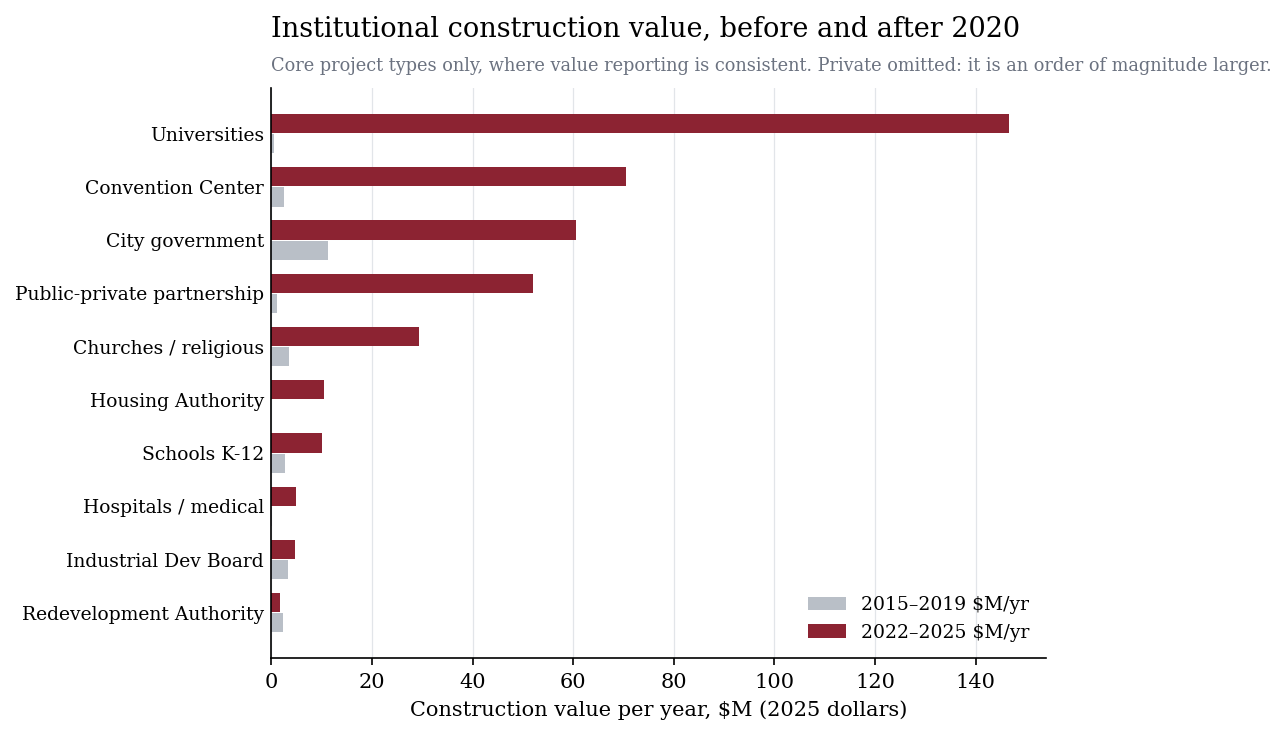

In [ ]:
# =============================================================================
# Construction value by owner category, before and after 2020
# =============================================================================
#
# RUN CELL O1 FIRST. This reuses the `category` column it creates.
#
# READ THIS BEFORE USING ANY NUMBER FROM THIS CELL
#
#   The ConstrVal field was not populated consistently over time. Across all
#   permits, the share carrying a construction value went from 37% in 2015 to
#   87% in 2022. Trade permits (electrical, HVAC, fuel gas) had almost no
#   values recorded early on and nearly full coverage later. That makes raw
#   year-over-year value totals non-comparable: later years look larger partly
#   because more permits got a value entered, not because more was built.
#
#   ConstVal restricted to core project types (new construction,
#   structural and non-structural renovation, demolition), where coverage is
#   stable at 90-98% across the whole period. CELL V1 prints that coverage
#   table first for separate verification

#   Figures are deflated to 2025 dollars using CPI-U annual
#   averages. Nominal comparisons across a decade with 30%+ cumulative
#   inflation are misleading.
#
#   STILL UNRESOLVED: some category-level percentages are implausibly large
#   (universities show +26,000%). Universities filed 25-77 permits a year
#   before 2020, but few were core-type permits with values. A possible
#   explanation is that university construction was recorded under contractor
#   or development-entity names earlier and under the university's own name
#   later. If so, part of the institutional surge is an owner-recording change
#   rather than a real shift. Report aggregate private-versus-institutional
#   comparison, treat individual category percentages as indicative only, and
#   do not quote a figure like +26,000% as a finding.
# =============================================================================


#### CELL V1 — value by owner category, with coverage check #####################

import numpy as np, pandas as pd, matplotlib.pyplot as plt

CORE_TYPES = ["New Construction", "Renovation (Structural)",
              "Renovation (Non-Structural)", "Demolition"]
PRE_YEARS, POST_YEARS = (2015, 2019), (2022, 2025)

# CPI-U annual averages (BLS, 1982-84 = 100). Extend as new years arrive.
CPI = {2015: 237.017, 2016: 240.007, 2017: 245.120, 2018: 251.107,
       2019: 255.657, 2020: 258.811, 2021: 270.970, 2022: 292.655,
       2023: 304.702, 2024: 313.689, 2025: 321.943}
BASE_YEAR = 2025

# ---- STEP 1: verify value coverage is stable before trusting any total ------
chk = d[d["yr"].between(PRE_YEARS[0], POST_YEARS[1])].copy()
cov_all  = chk.groupby("yr")["cv"].apply(lambda x: (x > 0).mean() * 100)
cov_core = (chk[chk["Type"].isin(CORE_TYPES)]
            .groupby("yr")["cv"].apply(lambda x: (x > 0).mean() * 100))
cov = pd.DataFrame({"all permits %": cov_all.round(1),
                    "core types %": cov_core.round(1)})
print("CONSTRUCTION VALUE COVERAGE BY YEAR")
print("If 'all permits' swings widely but 'core types' is flat, the restriction below is doing real work.\n")
display(cov)

spread = cov["core types %"].max() - cov["core types %"].min()
if spread > 20:
    print(f"\n  WARNING: core-type coverage varies by {spread:.0f} points. "
          "Value comparisons across years are not safe on this extract.")
else:
    print(f"\n  core-type coverage varies by only {spread:.0f} points: comparison is defensible.")

# ---- STEP 2: build the comparison on core types, in real dollars ------------
k = d[d["Type"].isin(CORE_TYPES) &
      d["yr"].between(PRE_YEARS[0], POST_YEARS[1])].copy()
k["deflator"] = k["yr"].map(lambda y: CPI[BASE_YEAR] / CPI[y] if y in CPI else np.nan)
k["val_real"] = k["val_counted"] * k["deflator"]

n_pre  = PRE_YEARS[1]  - PRE_YEARS[0]  + 1
n_post = POST_YEARS[1] - POST_YEARS[0] + 1
pre  = k[k["yr"].between(*PRE_YEARS)]
post = k[k["yr"].between(*POST_YEARS)]

pre_lbl  = f"{PRE_YEARS[0]}–{PRE_YEARS[1]} $M/yr"
post_lbl = f"{POST_YEARS[0]}–{POST_YEARS[1]} $M/yr"
t = pd.DataFrame({
    pre_lbl:  pre.groupby("category")["val_real"].sum()  / n_pre  / 1e6,
    post_lbl: post.groupby("category")["val_real"].sum() / n_post / 1e6,
}).fillna(0)

# suppress percentages off a near-zero base: they are noise dressed as findings
def fmt_change(r):
    if r[pre_lbl] < 1.0:
        return "n/a (base too small)"
    return f"{(r[post_lbl] / r[pre_lbl] - 1) * 100:+,.0f}%"
t["change"] = t.apply(fmt_change, axis=1)
t = t.round(1).sort_values(post_lbl, ascending=False)

print(f"\nCONSTRUCTION VALUE BY OWNER CATEGORY, {BASE_YEAR} dollars, core project types only")
display(t)

# ---- STEP 3: the aggregate comparison, which is the reportable finding ------
priv = t.loc["Private / other"]
inst = t.drop(index=["Private / other"]).sum(numeric_only=True)
print("=== THE REPORTABLE COMPARISON (real dollars, core project types) ===")
print(f"  Private / other:        ${priv[pre_lbl]:>7,.0f}M -> ${priv[post_lbl]:>7,.0f}M per year"
      f"   ({(priv[post_lbl]/priv[pre_lbl]-1)*100:+.1f}%)")
print(f"  Institutional + public: ${inst[pre_lbl]:>7,.0f}M -> ${inst[post_lbl]:>7,.0f}M per year")
print(f"\n  institutional share of construction value: "
      f"{inst[pre_lbl]/(inst[pre_lbl]+priv[pre_lbl])*100:.1f}% -> "
      f"{inst[post_lbl]/(inst[post_lbl]+priv[post_lbl])*100:.1f}%")

# ---- STEP 4: single-project concentration, the other value trap -------------
print("\n=== IS A CATEGORY JUST ONE BIG PROJECT? (post period) ===")
print("Over 50% means the category is a project, not a market. Do not describe it as a trend.\n")
for cat in t.drop(index=["Private / other"]).head(8).index:
    s = post[post["category"] == cat]
    if s["val_real"].sum() <= 0:
        continue
    share = s.groupby("proj_id")["val_real"].sum().max() / s["val_real"].sum() * 100
    flag = "   <-- one project dominates" if share > 50 else ""
    print(f"  {cat:28s} largest project = {share:5.1f}%{flag}")

# ---- chart ------------------------------------------------------------------
MAROON, GREY, INK, LIGHT = "#8C2332", "#b9bfc7", "#1c2129", "#e2e5e9"
plt.rcParams.update({"font.family": "serif", "figure.facecolor": "white"})

c = t.drop(index=["Private / other"])
c = c[(c[pre_lbl] >= 0.5) | (c[post_lbl] >= 0.5)].sort_values(post_lbl)

fig, ax = plt.subplots(figsize=(7.8, 5.0), dpi=150)
y = np.arange(len(c))
ax.barh(y - 0.19, c[pre_lbl],  height=.36, color=GREY,   label=pre_lbl)
ax.barh(y + 0.19, c[post_lbl], height=.36, color=MAROON, label=post_lbl)
ax.set_yticks(y); ax.set_yticklabels(c.index, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color=LIGHT, lw=.6); ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
ax.set_xlabel(f"Construction value per year, $M ({BASE_YEAR} dollars)", fontsize=10)
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title("Institutional construction value, before and after 2020",
             loc="left", fontsize=13, pad=25)
ax.text(0, 1.03, "Core project types only, where value reporting is consistent. "
        "Private omitted: it is an order of magnitude larger.",
        transform=ax.transAxes, fontsize=8.5, color="#6b7280")
plt.tight_layout(); plt.savefig("chart_owner_value.png", bbox_inches="tight")
plt.show()

t.to_csv("owner_value_comparison.csv")
cov.to_csv("value_coverage_check.csv")


In [ ]:
#### CELL 7 — download the outputs ##############################################
# Colab keeps files only for the session, so pull them down before you close it.

annual.to_csv("annual_summary.csv")
df.to_csv("permits_cleaned_full.csv", index=False)

from google.colab import files
#files.download("annual_summary.csv")
files.download("chart_permits.png")
files.download("chart_projects.png")
files.download("chart_value.png")
#files.download("neighborhood_summary.csv")
files.download("chart_neighborhood.png")
files.download("chart_decline_by_hood.png")
files.download("chart_held_up_best.png")
#files.download("concentration.csv")
files.download("chart_concentration.png")
#files.download("owner_project_comparison.csv")
files.download("chart_owner_projects.png")
#files.download("owner_value_comparison.csv")
#files.download("value_coverage_check.csv")
files.download("chart_owner_value.png")
# The cleaned full file is large; uncomment to download it too.
#   files.download("permits_cleaned_full.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>